In [1]:
pip install --upgrade torchvision

Note: you may need to restart the kernel to use updated packages.


In [1]:
import torch
import torch.nn as nn

class CNN3(nn.Module):

    def __init__(self):
        super().__init__()

        # Convolution 1
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=16,
            kernel_size=3,
            stride=1,
            padding=1
        )

        # Convolution 2
        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            stride=1,
            padding=1
        )

        # Convolution 3
        self.conv3 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            stride=1,
            padding=1
        )

        self.relu = nn.ReLU()

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.fc = nn.Linear(64 * 4 * 4, 10)

    def forward(self, x):

        # [3,32,32]
        x = self.conv1(x)
        # [16,32,32]

        x = self.relu(x)
        # [16,32,32]

        x = self.pool(x)
        # [16,16,16]

        x = self.conv2(x)
        # [32,16,16]

        x = self.relu(x)
        # [32,16,16]

        x = self.pool(x)
        # [32,8,8]

        x = self.conv3(x)
        # [64,8,8]

        x = self.relu(x)
        # [64,8,8]

        x = self.pool(x)
        # [64,4,4]

        x = torch.flatten(x, 1)
        # [1024]

        x = self.fc(x)
        # [10]

        return x

In [2]:
model3 = CNN3()

dummy_image = torch.randn(1, 3, 32, 32)

output = model3(dummy_image)

print("Input shape :", dummy_image.shape)
print("Output shape:", output.shape)
print("Output:", output)

Input shape : torch.Size([1, 3, 32, 32])
Output shape: torch.Size([1, 10])
Output: tensor([[ 0.1015,  0.0897,  0.0158,  0.1231, -0.1315, -0.1530, -0.0077, -0.0229,
          0.0134, -0.0135]], grad_fn=<AddmmBackward0>)


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


# ============================================================
# 1. Device
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)


# ============================================================
# 2. Transform images
# ============================================================

transform = transforms.ToTensor()


# ============================================================
# 3. Download CIFAR-10 dataset
# ============================================================

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


# ============================================================
# 4. DataLoader
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)


# ============================================================
# 5. Create CNN3
# ============================================================

model3 = CNN3()

model3 = model3.to(device)


# ============================================================
# 6. Loss function
# ============================================================

criterion = nn.CrossEntropyLoss()


# ============================================================
# 7. Optimizer
# ============================================================

optimizer = optim.Adam(
    model3.parameters(),
    lr=0.001
)


# ============================================================
# 8. Training
# ============================================================

epochs = 10

for epoch in range(epochs):

    model3.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        # Move data to CPU/GPU
        images = images.to(device)
        labels = labels.to(device)

        # --------------------------------
        # Forward pass
        # --------------------------------

        outputs = model3(images)

        # --------------------------------
        # Calculate loss
        # --------------------------------

        loss = criterion(outputs, labels)

        # --------------------------------
        # Clear old gradients
        # --------------------------------

        optimizer.zero_grad()

        # --------------------------------
        # Backward pass
        # --------------------------------

        loss.backward()

        # --------------------------------
        # Update weights
        # --------------------------------

        optimizer.step()

        # --------------------------------
        # Calculate accuracy
        # --------------------------------

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()


    accuracy = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {running_loss/len(train_loader):.4f} "
        f"Accuracy: {accuracy:.2f}%"
    )

Using device: cpu


C:\Users\amaiz\miniconda3\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Epoch [1/10] Loss: 1.6153 Accuracy: 41.89%
Epoch [2/10] Loss: 1.2509 Accuracy: 55.88%
Epoch [3/10] Loss: 1.1175 Accuracy: 60.92%
Epoch [4/10] Loss: 1.0286 Accuracy: 64.01%
Epoch [5/10] Loss: 0.9632 Accuracy: 66.54%
Epoch [6/10] Loss: 0.9143 Accuracy: 68.23%
Epoch [7/10] Loss: 0.8719 Accuracy: 69.76%
Epoch [8/10] Loss: 0.8359 Accuracy: 71.19%
Epoch [9/10] Loss: 0.8054 Accuracy: 72.04%
Epoch [10/10] Loss: 0.7842 Accuracy: 72.89%


In [4]:
# ==========================================
# TEST CNN3
# ==========================================

model3.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model3(images)

        # Get predicted class
        predicted = outputs.argmax(dim=1)

        # Count correct predictions
        total += labels.size(0)
        correct += (predicted == labels).sum().item()


test_accuracy = 100 * correct / total

print("Test Accuracy:", test_accuracy)

Test Accuracy: 69.61


Actual class    : cat
Predicted class : cat

Raw logits:
tensor([[-2.3297, -6.8805, -1.5793,  3.1034, -5.2547,  1.9588,  0.4406, -2.2381,
         -1.3343, -2.3256]])


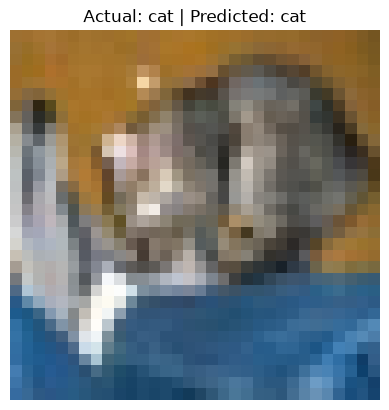

In [5]:
import matplotlib.pyplot as plt

classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]


# Evaluation mode
model3.eval()


# Take one unseen test image
image, label = test_dataset[0]


# Add batch dimension
image_input = image.unsqueeze(0).to(device)


# Model prediction
with torch.no_grad():

    logits = model3(image_input)


# Get predicted class
predicted_class = logits.argmax(dim=1).item()


print("Actual class    :", classes[label])
print("Predicted class :", classes[predicted_class])

print("\nRaw logits:")
print(logits)


# Show image
plt.imshow(image.permute(1, 2, 0))

plt.title(
    f"Actual: {classes[label]} | "
    f"Predicted: {classes[predicted_class]}"
)

plt.axis("off")
plt.show()

In [6]:
import torch.nn.functional as F

model3.eval()

image, label = test_dataset[0]

image_input = image.unsqueeze(0).to(device)

with torch.no_grad():

    logits = model3(image_input)

    # Convert logits to probabilities
    probabilities = F.softmax(logits, dim=1)

    # Find predicted class
    predicted_class = probabilities.argmax(dim=1).item()


print("Actual class    :", classes[label])
print("Predicted class :", classes[predicted_class])

print("\nLogits:")
print(logits)

print("\nProbabilities:")
print(probabilities)

print("\nProbabilities (%):")

for i in range(10):
    print(
        f"{classes[i]:12s}: "
        f"{probabilities[0][i].item() * 100:.2f}%"
    )

Actual class    : cat
Predicted class : cat

Logits:
tensor([[-2.3297, -6.8805, -1.5793,  3.1034, -5.2547,  1.9588,  0.4406, -2.2381,
         -1.3343, -2.3256]])

Probabilities:
tensor([[3.0707e-03, 3.2423e-05, 6.5033e-03, 7.0273e-01, 1.6479e-04, 2.2372e-01,
         4.9017e-02, 3.3653e-03, 8.3084e-03, 3.0833e-03]])

Probabilities (%):
airplane    : 0.31%
automobile  : 0.00%
bird        : 0.65%
cat         : 70.27%
deer        : 0.02%
dog         : 22.37%
frog        : 4.90%
horse       : 0.34%
ship        : 0.83%
truck       : 0.31%


In [7]:
import torch
import torch.nn as nn


class CNN5(nn.Module):

    def __init__(self):
        super().__init__()

        # Convolution 1
        self.conv1 = nn.Conv2d(3, 16, 3, stride=1, padding=1)

        # Convolution 2
        self.conv2 = nn.Conv2d(16, 32, 3, stride=1, padding=1)

        # Convolution 3
        self.conv3 = nn.Conv2d(32, 64, 3, stride=1, padding=1)

        # Convolution 4
        self.conv4 = nn.Conv2d(64, 64, 3, stride=1, padding=1)

        # Convolution 5
        self.conv5 = nn.Conv2d(64, 128, 3, stride=1, padding=1)

        self.relu = nn.ReLU()

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.fc = nn.Linear(128 * 4 * 4, 10)

    def forward(self, x):

        # [3,32,32]
        x = self.relu(self.conv1(x))
        # [16,32,32]

        x = self.pool(x)
        # [16,16,16]

        x = self.relu(self.conv2(x))
        # [32,16,16]

        x = self.pool(x)
        # [32,8,8]

        x = self.relu(self.conv3(x))
        # [64,8,8]

        x = self.relu(self.conv4(x))
        # [64,8,8]

        x = self.pool(x)
        # [64,4,4]

        x = self.relu(self.conv5(x))
        # [128,4,4]

        x = torch.flatten(x, 1)
        # [2048]

        x = self.fc(x)
        # [10]

        return x

In [8]:
model5 = CNN5()

dummy_image = torch.randn(1, 3, 32, 32)

output = model5(dummy_image)

print("Input shape :", dummy_image.shape)
print("Output shape:", output.shape)
print("Output:", output)

predicted_class = output.argmax(dim=1)

print("Predicted class:", predicted_class.item())

Input shape : torch.Size([1, 3, 32, 32])
Output shape: torch.Size([1, 10])
Output: tensor([[ 0.0018, -0.0006, -0.0121, -0.0027, -0.0304, -0.0112,  0.0253,  0.0019,
         -0.0207, -0.0215]], grad_fn=<AddmmBackward0>)
Predicted class: 6
